In [1]:
import os
os.environ['USER_AGENT'] = 'Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:47.0) Gecko/20100101 Firefox/47.0'
import langchain
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
import bs4
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langchain.agents import AgentExecutor, create_openai_tools_agent
langchain.__version__


'0.3.27'

In [2]:
with open("data/secrets/key.secret") as f:
    os.environ["OPENAI_API_KEY"] = f.read()

In [3]:
url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"

loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("mw-body-content",)
        )
    ),
)
docs = loader.load()
docs[0].page_content[:100]

'Type of information retrieval using LLMs\nRetrieval-augmented generation (RAG) is a technique that en'

In [4]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
len(all_splits)

31

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)
db = vector_store.add_documents(documents=all_splits)
len(db)

31

In [6]:
template="""
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use {nb} sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:
"""
prompt = ChatPromptTemplate.from_messages(
    [("user", template),("placeholder", "{agent_scratchpad}")]
)
prompt

ChatPromptTemplate(input_variables=['context', 'nb', 'question'], optional_variables=['agent_scratchpad'], input_types={'agent_scratchpad': list[typing.Annotated[typing.Union[typing.Annotated[langchain_core.messages.ai.AIMessage, Tag(tag='ai')], typing.Annotated[langchain_core.messages.human.HumanMessage, Tag(tag='human')], typing.Annotated[langchain_core.messages.chat.ChatMessage, Tag(tag='chat')], typing.Annotated[langchain_core.messages.system.SystemMessage, Tag(tag='system')], typing.Annotated[langchain_core.messages.function.FunctionMessage, Tag(tag='function')], typing.Annotated[langchain_core.messages.tool.ToolMessage, Tag(tag='tool')], typing.Annotated[langchain_core.messages.ai.AIMessageChunk, Tag(tag='AIMessageChunk')], typing.Annotated[langchain_core.messages.human.HumanMessageChunk, Tag(tag='HumanMessageChunk')], typing.Annotated[langchain_core.messages.chat.ChatMessageChunk, Tag(tag='ChatMessageChunk')], typing.Annotated[langchain_core.messages.system.SystemMessageChunk, T

In [7]:
llm = init_chat_model("gpt-4o-mini", model_provider="openai")

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content, "nb":3})
    response = llm.invoke(messages)
    return {"answer": response.content}



In [8]:
@tool
def add(a: int, b: int) -> int:
    """Adds a and b."""
    return a + b


@tool
def multiply(a: int, b: int) -> int:
    """Multiplies a and b."""
    print("Debug")
    return a * b

tools = [add, multiply]
tools_by_name = {tool.name: tool for tool in tools}
llm_with_tools = llm.bind_tools(tools)
print(multiply.name)
print(multiply.description)
print(multiply.args)

multiply
Multiplies a and b.
{'a': {'title': 'A', 'type': 'integer'}, 'b': {'title': 'B', 'type': 'integer'}}


In [9]:
tools = [add, multiply]
agent = create_openai_tools_agent(llm=llm, tools=tools, prompt=prompt)
agent_executor = AgentExecutor(agent=agent, tools=tools, verbose=True)


def run_agent(state: State) -> State:
    result = agent_executor.invoke({
        "question": state["question"],
        "nb":4,
        "context": "\n".join([doc.page_content for doc in state["context"]])
    })
    state["answer"] = result["output"]
    return state



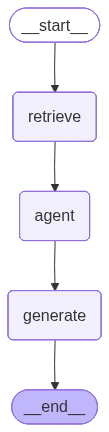

In [10]:
graph_builder = StateGraph(State)
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)
graph_builder.add_node("agent", run_agent)
graph_builder.add_edge("retrieve", "agent")
graph_builder.add_edge("agent", "generate")
graph_builder.add_edge(START, "retrieve")

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)
graph

In [11]:
config = {"configurable": {"thread_id": "uniqueId1234"}}
response = graph.invoke({"question": "Qu'est ce que le RAG et combien font 2 * 3?"}, config=config)
response["answer"]



> Entering new AgentExecutor chain...
Le RAG (Retrieval-Augmented Generation) est une méthode qui améliore les modèles de langage en intégrant la récupération d'informations avant de générer des réponses. Cela permet aux modèles de puiser dans des bases de données et d'autres sources pour fournir des informations plus pertinentes et précises. En ce qui concerne le calcul, 2 * 3 font 6.

> Finished chain.


"Le RAG (Retrieval-Augmented Generation) est une méthode qui améliore les modèles de langage en intégrant la recherche d'informations avant la génération de réponses, ce qui permet de combiner des documents externes et des données utilisateur. Cela permet d'accroître la précision des réponses tout en réduisant les hallucinations des intelligences artificielles. Quant à la question mathématique, 2 * 3 fait 6."